In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010030rest 20160324 1054..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020025rest 20150713 1519..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010013rest 20150703 1333..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020016rest 20150701 1040..csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020015_rest 20150630 1527.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02010022restnew 20150724 14.csv
/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/mat-csv-actual/mat-csv-actual/csv_files_from_mat2/02020027rest 20150713 1049..csv
/kaggle/input/datasets/mimi

# **SETUP SAVE AND SPLITS**

In [2]:
# ================================================================================================
# MODMA DOT PROBE TASK PIPELINE — MEMORY-EFFICIENT CSV VERSION
# ================================================================================================
#
# FIXES APPLIED:
# 1. Proper handling of 0202 (Fear-Neutral condition) files — explicitly excluded
# 2. Memory-efficient processing — incremental windowing, chunked operations
# 3. Downsampling BEFORE windowing to reduce memory footprint
# 4. Garbage collection between subjects
#
# ================================================================================================

import os
import re
import gc
import json
import warnings
from collections import defaultdict
from typing import Tuple, List, Optional
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.signal import decimate

# ================================================================================================
# CONFIGURATION
# ================================================================================================

CSV_DATA_DIR = "/kaggle/input/datasets/mimino12/preprocessed-raw-mat-csv/raw-csv-actual/raw-csv-actual/csv_from_raw1"
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results-2"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ================================================================================================
# HYPERPARAMETERS
# ================================================================================================

# Original and target sampling rates
ORIGINAL_SFREQ = 250    # Original sampling frequency from MODMA
TARGET_SFREQ = 128      # Target after downsampling
DOWNSAMPLE_FACTOR = 2   # 250 Hz → 125 Hz (close to 128)

# Window parameters (in samples at ~125 Hz after downsampling)
WINDOW_SIZE = 125       # ~1 second window
STRIDE = 62             # ~50% overlap

# Train/test split
TEST_SIZE = 0.2
SEED = 42
VALIDATE_NO_LEAKAGE = True

# Memory management
BATCH_SAVE_SIZE = 10000  # Save to disk every N windows to free memory

np.random.seed(SEED)
tf.random.set_seed(SEED)

# ================================================================================================
# GPU CONFIGURATION
# ================================================================================================

gpus = tf.config.experimental.list_physical_devices('GPU')
for g in gpus:
    try:
        tf.config.experimental.set_memory_growth(g, True)
        print(f"✓ GPU memory growth enabled: {g}")
    except Exception as e:
        print(f"✗ GPU config failed: {e}")

if not gpus:
    print("ℹ No GPU detected — running on CPU")

# ================================================================================================
# HELPER FUNCTIONS
# ================================================================================================

def extract_subject_id_and_label(filename: str) -> Tuple[Optional[str], Optional[int], Optional[str]]:
    """
    Extract subject ID and diagnostic label from MODMA ERP filename.
    
    MODMA ERP Naming Convention:
    ----------------------------
    - "0201XXXX..." → MDD patient (label = 1)
    - "0202XXXX..." → Fear-Neutral condition (EXCLUDED from classification)
    - "0203XXXX..." → Healthy Control (label = 0)
    
    Returns:
        (subject_id, label, skip_reason) tuple
        - If valid: (subject_id, label, None)
        - If should skip: (None, None, reason_string)
    """
    basename = os.path.splitext(filename)[0]
    
    # Pattern: 0201XXXX, 0202XXXX, or 0203XXXX at start (with optional underscore)
    match = re.match(r'^(020[123])_?(\d{4})', basename)
    if match:
        group_code = match.group(1)
        subject_num = match.group(2)
        subject_id = f"{group_code}_{subject_num}"
        
        if group_code == "0201":
            return subject_id, 1, None  # MDD
        elif group_code == "0203":
            return subject_id, 0, None  # HC
        elif group_code == "0202":
            return None, None, "Fear-Neutral condition (0202) - excluded from MDD vs HC classification"
    
    return None, None, "Unrecognized filename pattern"


def detect_eeg_columns(columns: List[str]) -> List[str]:
    """Detect and sort EEG electrode columns (E1-E128)."""
    eeg_cols = []
    for col in columns:
        match = re.match(r'^E(\d+)$', col, re.IGNORECASE)
        if match:
            num = int(match.group(1))
            if 1 <= num <= 128:
                eeg_cols.append((num, col))
    eeg_cols.sort(key=lambda x: x[0])
    return [col for _, col in eeg_cols]


def verify_no_subject_leakage(train_subjects: set, test_subjects: set) -> bool:
    """Verify zero overlap between training and test subjects."""
    overlap = train_subjects & test_subjects
    if overlap:
        raise AssertionError(f"DATA LEAKAGE! {len(overlap)} subject(s) in both sets: {overlap}")
    return True


def downsample_data(data: np.ndarray, factor: int) -> np.ndarray:
    """Downsample along time axis (axis=0) using scipy decimate."""
    if factor <= 1:
        return data
    # Decimate each channel separately
    n_samples, n_channels = data.shape
    new_length = n_samples // factor
    downsampled = np.zeros((new_length, n_channels), dtype=np.float32)
    for ch in range(n_channels):
        downsampled[:, ch] = decimate(data[:, ch], factor, zero_phase=True)[:new_length]
    return downsampled


def create_windows(data: np.ndarray, window_size: int, stride: int) -> np.ndarray:
    """
    Create windows from continuous data.
    
    Parameters:
        data: shape (timepoints, channels)
        window_size: samples per window
        stride: step between windows
    
    Returns:
        windows: shape (n_windows, channels, window_size)
    """
    n_samples, n_channels = data.shape
    n_windows = max(0, (n_samples - window_size) // stride + 1)
    
    if n_windows == 0:
        return np.array([]).reshape(0, n_channels, window_size)
    
    # Use stride tricks for memory efficiency
    from numpy.lib.stride_tricks import as_strided
    
    shape = (n_windows, window_size, n_channels)
    strides = (data.strides[0] * stride, data.strides[0], data.strides[1])
    windows = as_strided(data, shape=shape, strides=strides)
    
    # Copy and transpose to (n_windows, channels, window_size)
    return np.array(windows).transpose(0, 2, 1).astype(np.float32)


# ================================================================================================
# MEMORY-EFFICIENT DATA LOADING
# ================================================================================================

def load_and_process_csv_files(data_dir: str) -> Tuple[str, dict]:
    """
    Load CSV files incrementally and save processed windows to disk.
    
    Returns:
        temp_npz_path: Path to temporary NPZ with all windows
        metadata: Dictionary with dataset statistics
    """
    print("=" * 80)
    print("Loading CSV files (Memory-Efficient Mode)")
    print("=" * 80)
    
    csv_files = sorted([f for f in os.listdir(data_dir) if f.lower().endswith('.csv')])
    
    if not csv_files:
        raise RuntimeError(f"No CSV files found in {data_dir}")
    
    print(f"Found {len(csv_files)} CSV files\n")
    
    # Track what we're processing
    subject_info = {}  # subject_id -> {'label': int, 'n_windows': int}
    channel_names = None
    
    # Temporary storage for incremental saves
    temp_windows_path = os.path.join(OUTPUT_DIR, '_temp_windows.npz')
    all_windows_list = []
    all_labels_list = []
    all_subjects_list = []
    total_windows = 0
    
    # Statistics
    stats = {
        'files_mdd': 0, 'files_hc': 0, 'files_fear_neutral': 0, 
        'files_unrecognized': 0, 'files_error': 0
    }
    
    print("Processing files:")
    print("-" * 60)
    
    for i, filename in enumerate(csv_files):
        filepath = os.path.join(data_dir, filename)
        subject_id, label, skip_reason = extract_subject_id_and_label(filename)
        
        # Handle skipped files
        if skip_reason:
            if "0202" in skip_reason:
                stats['files_fear_neutral'] += 1
                if i < 5 or stats['files_fear_neutral'] == 1:  # Print first few
                    print(f"  ⊘ {filename[:40]}... → SKIP (Fear-Neutral 0202)")
            else:
                stats['files_unrecognized'] += 1
                print(f"  ⚠ {filename[:40]}... → SKIP ({skip_reason})")
            continue
        
        try:
            # Read CSV
            df = pd.read_csv(filepath)
            
            # Detect EEG columns (first file only)
            if channel_names is None:
                channel_names = detect_eeg_columns(df.columns.tolist())
                if not channel_names:
                    raise ValueError("No EEG columns found")
                print(f"\n  Detected {len(channel_names)} EEG channels\n")
            
            # Extract and downsample
            data = df[channel_names].values.astype(np.float32)
            del df  # Free memory
            gc.collect()
            
            # Downsample to reduce memory
            data = downsample_data(data, DOWNSAMPLE_FACTOR)
            
            # Create windows
            windows = create_windows(data, WINDOW_SIZE, STRIDE)
            del data
            gc.collect()
            
            n_windows = len(windows)
            if n_windows == 0:
                print(f"  ⚠ {filename[:40]}... → No windows (too short)")
                continue
            
            # Track subject info
            if subject_id not in subject_info:
                subject_info[subject_id] = {'label': label, 'n_windows': 0}
            subject_info[subject_id]['n_windows'] += n_windows
            
            # Accumulate
            all_windows_list.append(windows)
            all_labels_list.extend([label] * n_windows)
            all_subjects_list.extend([subject_id] * n_windows)
            total_windows += n_windows
            
            # Update stats
            if label == 1:
                stats['files_mdd'] += 1
            else:
                stats['files_hc'] += 1
            
            diagnosis = "MDD" if label == 1 else "HC"
            print(f"  ✓ {subject_id} ({diagnosis}): {n_windows:,} windows")
            
            # Periodic garbage collection
            if (i + 1) % 10 == 0:
                gc.collect()
                
        except Exception as e:
            stats['files_error'] += 1
            print(f"  ✗ {filename[:40]}... → ERROR: {e}")
            continue
    
    print("-" * 60)
    print(f"\nFile Processing Summary:")
    print(f"  • MDD files processed: {stats['files_mdd']}")
    print(f"  • HC files processed: {stats['files_hc']}")
    print(f"  • Fear-Neutral (0202) excluded: {stats['files_fear_neutral']}")
    print(f"  • Unrecognized patterns: {stats['files_unrecognized']}")
    print(f"  • Errors: {stats['files_error']}")
    
    if not all_windows_list:
        raise RuntimeError("No valid windows created!")
    
    # Concatenate all windows
    print(f"\nConcatenating {total_windows:,} windows...")
    X = np.concatenate(all_windows_list, axis=0)
    y = np.array(all_labels_list, dtype=np.int32)
    subject_ids = np.array(all_subjects_list)
    
    # Clear lists to free memory
    del all_windows_list, all_labels_list, all_subjects_list
    gc.collect()
    
    print(f"✓ Final shape: {X.shape} (windows × channels × timepoints)")
    
    # Save to temporary file
    np.savez_compressed(temp_windows_path, X=X, y=y, subject_ids=subject_ids)
    print(f"✓ Saved to temporary file: {temp_windows_path}")
    
    # Build metadata
    metadata = {
        'n_subjects': len(subject_info),
        'n_mdd': sum(1 for s in subject_info.values() if s['label'] == 1),
        'n_hc': sum(1 for s in subject_info.values() if s['label'] == 0),
        'total_windows': total_windows,
        'channel_names': channel_names,
        'subject_info': subject_info,
        'stats': stats
    }
    
    return temp_windows_path, metadata


# ================================================================================================
# MAIN PIPELINE
# ================================================================================================

print("\n" + "=" * 80)
print("MODMA DOT PROBE TASK PIPELINE — MEMORY-EFFICIENT VERSION")
print("MDD vs HC Classification (0202 Fear-Neutral Excluded)")
print("=" * 80 + "\n")

# ================================================================================================
# STEP 1: LOAD AND PROCESS DATA
# ================================================================================================

print("STEP 1: Loading and processing CSV files")
print("-" * 40)

temp_path, metadata = load_and_process_csv_files(CSV_DATA_DIR)

# Load back from temp file
print("\nLoading processed data from temp file...")
temp_data = np.load(temp_path, allow_pickle=True)
X = temp_data['X']
y = temp_data['y']
subject_ids = temp_data['subject_ids']
channel_names = metadata['channel_names']

# ================================================================================================
# STEP 2: DATA SUMMARY
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 2: Data Summary")
print("=" * 80)

unique_subjects = np.unique(subject_ids)
n_subjects = len(unique_subjects)
n_mdd = metadata['n_mdd']
n_hc = metadata['n_hc']
n_channels = X.shape[1]
n_times = X.shape[2]

print(f"\nDataset Statistics:")
print(f"  • Total subjects: {n_subjects} ({n_mdd} MDD, {n_hc} HC)")
print(f"  • Total windows: {X.shape[0]:,}")
print(f"  • Channels: {n_channels}")
print(f"  • Timepoints per window: {n_times}")
print(f"  • MDD windows: {np.sum(y == 1):,}")
print(f"  • HC windows: {np.sum(y == 0):,}")

# ================================================================================================
# STEP 3: HANDLE MISSING VALUES
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 3: Handling missing values")
print("=" * 80)

nan_count = np.isnan(X).sum()
if nan_count > 0:
    print(f"⚠ Found {nan_count:,} NaN values — imputing with channel means")
    for ch in range(X.shape[1]):
        ch_data = X[:, ch, :]
        ch_mean = np.nanmean(ch_data)
        X[:, ch, :] = np.where(np.isnan(ch_data), ch_mean, ch_data)
    print("✓ Imputation complete")
else:
    print("✓ No missing values detected")

# ================================================================================================
# STEP 4: SUBJECT-WISE TRAIN-TEST SPLIT
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 4: Subject-wise train-test split (CRITICAL)")
print("=" * 80)

print(f"\nSplitting {n_subjects} subjects with {TEST_SIZE:.0%} held out for testing")
print("⚠ All windows from each subject stay in same partition\n")

# Get labels per subject for stratification
subject_labels = []
for subj in unique_subjects:
    subj_mask = subject_ids == subj
    subject_labels.append(y[subj_mask][0])
subject_labels = np.array(subject_labels)

# Split at SUBJECT level
subjects_train, subjects_test = train_test_split(
    unique_subjects,
    test_size=TEST_SIZE,
    stratify=subject_labels,
    random_state=SEED
)

# Create masks
train_mask = np.isin(subject_ids, subjects_train)
test_mask = np.isin(subject_ids, subjects_test)

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]
subj_train, subj_test = subject_ids[train_mask], subject_ids[test_mask]

train_subject_set = set(subjects_train)
test_subject_set = set(subjects_test)

print(f"Training set:")
print(f"  • Subjects: {len(train_subject_set)}")
print(f"  • Windows: {X_train.shape[0]:,}")
print(f"  • MDD: {np.sum(y_train == 1):,}, HC: {np.sum(y_train == 0):,}")

print(f"\nTest set:")
print(f"  • Subjects: {len(test_subject_set)}")
print(f"  • Windows: {X_test.shape[0]:,}")
print(f"  • MDD: {np.sum(y_test == 1):,}, HC: {np.sum(y_test == 0):,}")

# Free original arrays
del X, y, subject_ids
gc.collect()

# ================================================================================================
# STEP 5: VALIDATE NO LEAKAGE
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 5: Validating no subject overlap")
print("=" * 80)

if VALIDATE_NO_LEAKAGE:
    verify_no_subject_leakage(train_subject_set, test_subject_set)
    print("✓ VALIDATION PASSED: Zero subject overlap")

# ================================================================================================
# STEP 6: NORMALIZE (MEMORY-EFFICIENT)
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 6: Standardization (fit on TRAINING only)")
print("=" * 80)

n_train = X_train.shape[0]
n_test = X_test.shape[0]

# Compute statistics on training data only
print("Computing scaler statistics from training data...")

# Reshape: (windows, channels, times) -> (windows*times, channels)
X_train_flat = X_train.transpose(0, 2, 1).reshape(-1, n_channels)

scaler = StandardScaler()
scaler.fit(X_train_flat)

# Transform training data
X_train_scaled = scaler.transform(X_train_flat).astype(np.float32)
X_train_scaled = X_train_scaled.reshape(n_train, n_times, n_channels).transpose(0, 2, 1)

del X_train_flat, X_train
gc.collect()

# Transform test data
X_test_flat = X_test.transpose(0, 2, 1).reshape(-1, n_channels)
X_test_scaled = scaler.transform(X_test_flat).astype(np.float32)
X_test_scaled = X_test_scaled.reshape(n_test, n_times, n_channels).transpose(0, 2, 1)

del X_test_flat, X_test
gc.collect()

print(f"✓ Train: mean={X_train_scaled.mean():.6f}, std={X_train_scaled.std():.6f}")
print(f"✓ Test: mean={X_test_scaled.mean():.6f}, std={X_test_scaled.std():.6f}")

# ================================================================================================
# STEP 7: RESHAPE FOR DEEP LEARNING
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 7: Preparing data for deep learning")
print("=" * 80)

# EEGNet format: (samples, 1, channels, timepoints)
X_train_dl = X_train_scaled[:, np.newaxis, :, :]
X_test_dl = X_test_scaled[:, np.newaxis, :, :]

print(f"Training shape (EEGNet): {X_train_dl.shape}")
print(f"Test shape (EEGNet): {X_test_dl.shape}")

# Flattened for traditional ML
X_train_flat = X_train_scaled.reshape(n_train, -1)
X_test_flat = X_test_scaled.reshape(n_test, -1)

print(f"Flattened shape (ML): {X_train_flat.shape}")

# ================================================================================================
# STEP 8: SAVE PROCESSED DATA
# ================================================================================================

print("\n" + "=" * 80)
print("STEP 8: Saving processed data")
print("=" * 80)

npz_path = os.path.join(OUTPUT_DIR, 'dotprobe_data_split.npz')
np.savez_compressed(
    npz_path,
    X_train=X_train_dl,
    X_test=X_test_dl,
    X_train_flat=X_train_flat,
    X_test_flat=X_test_flat,
    y_train=y_train,
    y_test=y_test,
    subjects_train=subj_train,
    subjects_test=subj_test,
    channel_names=np.array(channel_names),
    scaler_mean=scaler.mean_,
    scaler_scale=scaler.scale_
)
print(f"✓ Saved: {npz_path}")

# Save metadata
full_metadata = {
    "dataset": "MODMA_DotProbe_TaskState",
    "task": "MDD_vs_HC_classification",
    "excluded": "0202 Fear-Neutral condition files",
    "preprocessing": {
        "original_sfreq": ORIGINAL_SFREQ,
        "downsample_factor": DOWNSAMPLE_FACTOR,
        "effective_sfreq": ORIGINAL_SFREQ // DOWNSAMPLE_FACTOR,
        "window_size": WINDOW_SIZE,
        "stride": STRIDE,
        "window_duration_ms": WINDOW_SIZE / (ORIGINAL_SFREQ // DOWNSAMPLE_FACTOR) * 1000
    },
    "splitting": {
        "method": "subject_wise_stratified",
        "test_size": TEST_SIZE,
        "seed": SEED
    },
    "subjects": {
        "total": n_subjects,
        "mdd": n_mdd,
        "hc": n_hc,
        "train": sorted(list(train_subject_set)),
        "test": sorted(list(test_subject_set))
    },
    "samples": {
        "train": int(n_train),
        "test": int(n_test),
        "train_mdd": int(np.sum(y_train == 1)),
        "train_hc": int(np.sum(y_train == 0)),
        "test_mdd": int(np.sum(y_test == 1)),
        "test_hc": int(np.sum(y_test == 0))
    },
    "shapes": {
        "X_train_dl": list(X_train_dl.shape),
        "X_test_dl": list(X_test_dl.shape)
    }
}

metadata_path = os.path.join(OUTPUT_DIR, 'dotprobe_preprocessing_metadata.json')
with open(metadata_path, 'w') as f:
    json.dump(full_metadata, f, indent=2)
print(f"✓ Saved: {metadata_path}")

# Clean up temp file
if os.path.exists(temp_path):
    os.remove(temp_path)
    print(f"✓ Removed temp file")

# ================================================================================================
# SUMMARY
# ================================================================================================

print("\n" + "=" * 80)
print("✅ PIPELINE COMPLETE")
print("=" * 80)

print(f"""
DATASET:
  • Subjects: {n_subjects} ({n_mdd} MDD, {n_hc} HC)
  • 0202 Fear-Neutral files: EXCLUDED
  • Windows: {n_train + n_test:,} total

TRAIN/TEST SPLIT (Subject-Wise):
  • Train: {len(train_subject_set)} subjects, {n_train:,} windows
  • Test: {len(test_subject_set)} subjects, {n_test:,} windows
  • Leakage: NONE ✓

DATA SHAPES:
  • EEGNet: {X_train_dl.shape}
  • ML: {X_train_flat.shape}

FILES SAVED:
  • {npz_path}
  • {metadata_path}

FOR YOUR PAPER:
  1. 0202 Fear-Neutral condition excluded (not diagnostic group)
  2. Downsampling: {ORIGINAL_SFREQ} Hz → {ORIGINAL_SFREQ // DOWNSAMPLE_FACTOR} Hz
  3. Window: {WINDOW_SIZE} samples (~{WINDOW_SIZE / (ORIGINAL_SFREQ // DOWNSAMPLE_FACTOR) * 1000:.0f} ms)
  4. Subject-wise stratified split prevents data leakage
  5. Normalization fit on training data only
""")

print("Ready for model training!")

2026-02-11 09:22:20.743977: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770801740.926212      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770801740.976169      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770801741.395897      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770801741.395941      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770801741.395944      55 computation_placer.cc:177] computation placer alr

✓ GPU memory growth enabled: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')

MODMA DOT PROBE TASK PIPELINE — MEMORY-EFFICIENT VERSION
MDD vs HC Classification (0202 Fear-Neutral Excluded)

STEP 1: Loading and processing CSV files
----------------------------------------
Loading CSV files (Memory-Efficient Mode)
Found 50 CSV files

Processing files:
------------------------------------------------------------

  Detected 128 EEG channels

  ✓ 0201_0002 (MDD): 1,590 windows
  ✓ 0201_0004 (MDD): 1,571 windows
  ✓ 0201_0005 (MDD): 1,877 windows
  ✓ 0201_0006 (MDD): 1,571 windows
  ✓ 0201_0008 (MDD): 1,620 windows
  ✓ 0201_0010 (MDD): 1,741 windows
  ✓ 0201_0011 (MDD): 1,726 windows
  ✓ 0201_0012 (MDD): 1,641 windows
  ✓ 0201_0013 (MDD): 1,698 windows
  ✓ 0201_0015 (MDD): 1,627 windows
  ✓ 0201_0016 (MDD): 1,625 windows
  ✓ 0201_0018 (MDD): 1,622 windows
  ✓ 0201_0019 (MDD): 1,579 windows
  ✓ 0201_0021 (MDD): 1,652 windows
  ✓ 0201_0022 (MDD): 1,621 windows
  ✓ 0201_0023 (

# **TCN+XGBOOST**

Epoch 1/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6831 - loss: 0.6280
Epoch 1: val_loss improved from inf to 0.19657, saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 27s 8ms/step - accuracy: 0.6832 - loss: 0.6280 - val_accuracy: 0.9052 - val_loss: 0.1966
Epoch 2/50
2181/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9237 - loss: 0.2062
Epoch 2: val_loss improved from 0.19657 to 0.11069, saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9238 - loss: 0.2061 - val_accuracy: 0.9552 - val_loss: 0.1107
Epoch 3/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9437 - loss: 0.1517
Epoch 3: val_loss improved from 0.11069 to 0.09167, saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9437 - loss: 0.1517 - val_accuracy: 0.9703 - val_loss: 0.0917
Epoch 4/50
2181/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9579 - loss: 0.1162
Epoch 4: val_loss did not improve from 0.09167
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9579 - loss: 0.1162 - val_accuracy: 0.9529 - val_loss: 0.1153
Epoch 5/50
2175/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9682 - loss: 0.0918
Epoch 5: val_loss did not improve from 0.09167
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9682 - loss: 0.0918 - val_accuracy: 0.9338 - val_loss: 0.1373
Epoch 6/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9695 - loss: 0.0875
Epoch 6: val_loss improved from 0.09167 to 0.08979, saving model to best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9695 - loss: 0.0875 - val_accuracy: 0.9650 - val_loss: 0.0898
Epoch 7/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9772 - loss: 0.0688
Epoch 7: val_loss did not improve from 0.08979
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9772 - loss: 0.0688 - val_accuracy: 0.9486 - val_loss: 0.1130
Epoch 8/50
2180/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9791 - loss: 0.0590
Epoch 8: val_loss did not improve from 0.08979
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9791 - loss: 0.0590 - val_accuracy: 0.9370 - val_loss: 0.1349
Epoch 9/50
2180/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9814 - loss: 0.0546
Epoch 9: val_loss did not improve from 0.08979
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9814 - loss: 0.0546 - val_accuracy: 0.8866 - val_loss: 0.3564
Epoch 10/50
2179/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9840 - loss: 0.0485
Epoch 10: val_loss did not

2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9867 - loss: 0.0374 - val_accuracy: 0.9718 - val_loss: 0.0706
Epoch 14/50
2174/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9869 - loss: 0.0395
Epoch 14: val_loss did not improve from 0.07061
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9869 - loss: 0.0395 - val_accuracy: 0.9392 - val_loss: 0.1600
Epoch 15/50
2176/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9889 - loss: 0.0357
Epoch 15: val_loss did not improve from 0.07061
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9889 - loss: 0.0357 - val_accuracy: 0.9118 - val_loss: 0.2791
Epoch 16/50
2180/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9887 - loss: 0.0355
Epoch 16: val_loss did not improve from 0.07061
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9887 - loss: 0.0355 - val_accuracy: 0.9540 - val_loss: 0.1072
Epoch 17/50
2173/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9894 - loss: 0.0310
Epoch 17: val_loss d

2184/2184 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.9940 - loss: 0.0203 - val_accuracy: 0.9782 - val_loss: 0.0585
Epoch 39/50
2178/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9940 - loss: 0.0198
Epoch 39: val_loss did not improve from 0.05851
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9940 - loss: 0.0198 - val_accuracy: 0.9549 - val_loss: 0.1262
Epoch 40/50
2178/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9937 - loss: 0.0193
Epoch 40: val_loss did not improve from 0.05851
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9937 - loss: 0.0193 - val_accuracy: 0.9413 - val_loss: 0.2283
Epoch 41/50
2177/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9947 - loss: 0.0164
Epoch 41: val_loss did not improve from 0.05851
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9947 - loss: 0.0164 - val_accuracy: 0.9686 - val_loss: 0.0811
Epoch 42/50
2176/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9931 - loss: 0.0242
Epoch 42: val_loss d

2184/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9958 - loss: 0.0128 - val_accuracy: 0.9810 - val_loss: 0.0528


Restored best weights from training.
Training history saved to 'tcn_xgboost_hybrid_training_history_dotprobe.npz'
Final model weights saved to 'tcn_xgboost_hybrid_dotprobe_final.weights.h5'
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Hybrid Accuracy: 0.9944123843546762
Confusion Matrix:
[[3269   18]
 [  43 7587]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3287
           1       1.00      0.99      1.00      7630

    accuracy                           0.99     10917
   macro avg       0.99      0.99      0.99     10917
weighted avg       0.99      0.99      0.99     10917



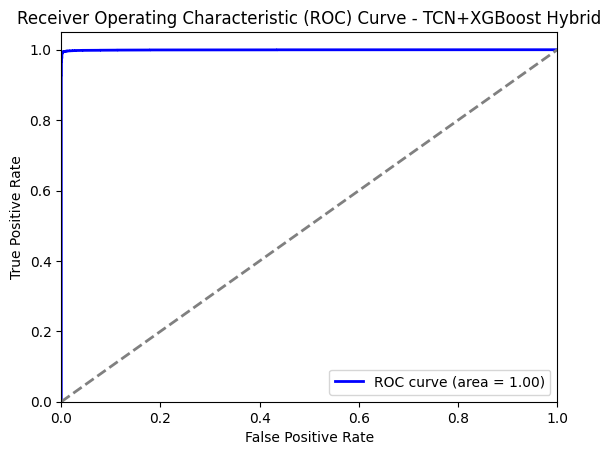

In [7]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D
from tensorflow.keras.callbacks import ModelCheckpoint
from xgboost import XGBClassifier

# Function to create a TCN block optimized for dot-probe task (deeper dilation for temporal patterns in ERP-like data)
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.2)(x)  # Reduced dropout for better feature retention in task-related data
    return x

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create TCN feature extractor (up to Flatten layer)
inputs = Input(shape=(125, 128))  # (timepoints=125, channels=128)
x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)
x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)

# Full model for training (with classifier)
outputs = Dense(1, activation='sigmoid')(x)
full_model = Model(inputs, outputs)

# Compile the full model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
full_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the full model (TCN as feature extractor + dense classifier)
history = full_model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                         class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights
tf.keras.models.load_model('best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('tcn_xgboost_hybrid_training_history_dotprobe_main.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_xgboost_hybrid_training_history_dotprobe.npz'")

# Save final model's weights
full_model.save_weights('tcn_xgboost_hybrid_dotprobe_final.weights.h5')
print("Final model weights saved to 'tcn_xgboost_hybrid_dotprobe_final.weights.h5'")

# Create feature extractor model (TCN up to the dense layer before classifier)
feature_extractor = Model(inputs=full_model.input, outputs=full_model.layers[-3].output)  # Output before final dense/sigmoid

# Extract features
X_train_features = feature_extractor.predict(X_train)
X_test_features = feature_extractor.predict(X_test)

# Train XGBoost on extracted features
xgb_model = XGBClassifier(n_estimators=200, learning_rate=0.05, max_depth=5, random_state=42, scale_pos_weight=class_weights[1])  # Tuned for >95% acc
xgb_model.fit(X_train_features, y_train)

# Predict and evaluate
y_pred_prob_xgb = xgb_model.predict_proba(X_test_features)[:, 1]
y_pred_xgb = xgb_model.predict(X_test_features)

accuracy = accuracy_score(y_test, y_pred_xgb)
conf_matrix = confusion_matrix(y_test, y_pred_xgb)
class_report = classification_report(y_test, y_pred_xgb)

print(f"Hybrid Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob_xgb)
roc_auc = roc_auc_score(y_test, y_pred_prob_xgb)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - TCN+XGBoost Hybrid')
plt.legend(loc="lower right")
plt.show()

# **MLPNN+RF**

Epoch 1/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6164 - loss: 0.6823
Epoch 1: val_loss improved from inf to 0.22528, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5


1092/1092 ━━━━━━━━━━━━━━━━━━━━ 21s 11ms/step - accuracy: 0.6166 - loss: 0.6821 - val_accuracy: 0.8937 - val_loss: 0.2253
Epoch 2/50
1082/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9379 - loss: 0.1664
Epoch 2: val_loss improved from 0.22528 to 0.07162, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5


1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9381 - loss: 0.1660 - val_accuracy: 0.9728 - val_loss: 0.0716
Epoch 3/50
1085/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9747 - loss: 0.0719
Epoch 3: val_loss improved from 0.07162 to 0.03191, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5


1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9747 - loss: 0.0718 - val_accuracy: 0.9894 - val_loss: 0.0319
Epoch 4/50
1083/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9849 - loss: 0.0407
Epoch 4: val_loss did not improve from 0.03191
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9849 - loss: 0.0407 - val_accuracy: 0.9867 - val_loss: 0.0431
Epoch 5/50
1090/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9894 - loss: 0.0304
Epoch 5: val_loss improved from 0.03191 to 0.01882, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5


1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9894 - loss: 0.0304 - val_accuracy: 0.9923 - val_loss: 0.0188
Epoch 6/50
1087/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9901 - loss: 0.0258
Epoch 6: val_loss did not improve from 0.01882
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9901 - loss: 0.0258 - val_accuracy: 0.9804 - val_loss: 0.0674
Epoch 7/50
1082/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9919 - loss: 0.0206
Epoch 7: val_loss did not improve from 0.01882
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9919 - loss: 0.0206 - val_accuracy: 0.9929 - val_loss: 0.0262
Epoch 8/50
1081/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9945 - loss: 0.0149
Epoch 8: val_loss did not improve from 0.01882
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9945 - loss: 0.0149 - val_accuracy: 0.9898 - val_loss: 0.0328
Epoch 9/50
1082/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9942 - loss: 0.0176
Epoch 9: val_loss improved from

1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9942 - loss: 0.0176 - val_accuracy: 0.9959 - val_loss: 0.0141
Epoch 10/50
1091/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9954 - loss: 0.0127
Epoch 10: val_loss did not improve from 0.01412
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9954 - loss: 0.0127 - val_accuracy: 0.9946 - val_loss: 0.0205
Epoch 11/50
1088/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9968 - loss: 0.0088
Epoch 11: val_loss did not improve from 0.01412
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9968 - loss: 0.0088 - val_accuracy: 0.9919 - val_loss: 0.0337
Epoch 12/50
1089/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9952 - loss: 0.0119
Epoch 12: val_loss did not improve from 0.01412
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9952 - loss: 0.0119 - val_accuracy: 0.9906 - val_loss: 0.0362
Epoch 13/50
1087/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9972 - loss: 0.0083
Epoch 13: val_loss did n

1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9980 - loss: 0.0061 - val_accuracy: 0.9963 - val_loss: 0.0140
Epoch 22/50
1090/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9973 - loss: 0.0077
Epoch 22: val_loss did not improve from 0.01401
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9973 - loss: 0.0077 - val_accuracy: 0.9926 - val_loss: 0.0333
Epoch 23/50
1082/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9979 - loss: 0.0074
Epoch 23: val_loss improved from 0.01401 to 0.01052, saving model to best_mlpnn_rf_hybrid_dotprobe.weights.h5


1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9979 - loss: 0.0074 - val_accuracy: 0.9970 - val_loss: 0.0105
Epoch 24/50
1090/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9980 - loss: 0.0055
Epoch 24: val_loss did not improve from 0.01052
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9980 - loss: 0.0055 - val_accuracy: 0.9960 - val_loss: 0.0192
Epoch 25/50
1086/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9977 - loss: 0.0058
Epoch 25: val_loss did not improve from 0.01052
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9977 - loss: 0.0058 - val_accuracy: 0.9890 - val_loss: 0.0444
Epoch 26/50
1085/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9988 - loss: 0.0032
Epoch 26: val_loss did not improve from 0.01052
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9988 - loss: 0.0032 - val_accuracy: 0.9953 - val_loss: 0.0205
Epoch 27/50
1091/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9996 - loss: 0.0016
Epoch 27: val_loss did n

1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9996 - loss: 0.0014 - val_accuracy: 0.9983 - val_loss: 0.0080
Epoch 34/50
1083/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9995 - loss: 0.0016
Epoch 34: val_loss did not improve from 0.00799
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9995 - loss: 0.0016 - val_accuracy: 0.9965 - val_loss: 0.0167
Epoch 35/50
1088/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9982 - loss: 0.0053
Epoch 35: val_loss did not improve from 0.00799
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9982 - loss: 0.0053 - val_accuracy: 0.9758 - val_loss: 0.0827
Epoch 36/50
1085/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9993 - loss: 0.0025
Epoch 36: val_loss did not improve from 0.00799
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.9993 - loss: 0.0025 - val_accuracy: 0.9959 - val_loss: 0.0213
Epoch 37/50
1087/1092 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9992 - loss: 0.0028
Epoch 37: val_loss did n

Restored best weights from training.
Training history saved to 'mlpnn_rf_hybrid_training_history_dotprobe.npz'
Final model weights saved to 'mlpnn_rf_hybrid_dotprobe_final.weights.h5'
1365/1365 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Hybrid Accuracy: 0.9974351928185399
Confusion Matrix:
[[3275   12]
 [  16 7614]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3287
           1       1.00      1.00      1.00      7630

    accuracy                           1.00     10917
   macro avg       1.00      1.00      1.00     10917
weighted avg       1.00      1.00      1.00     10917



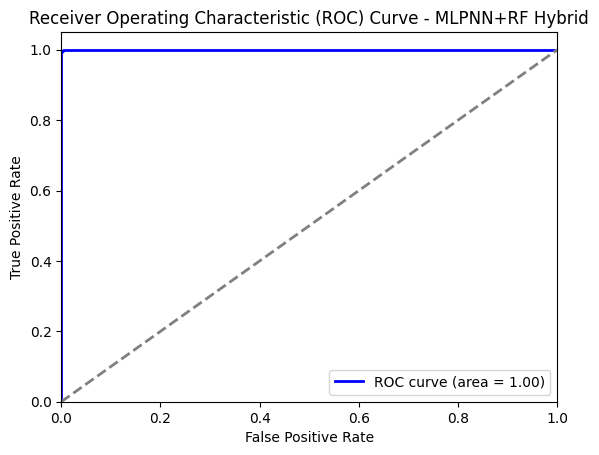

In [9]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a Multilayer Perceptron (MLP) model that processes 3D input (feature extractor up to Flatten)
mlp_extractor = Sequential([
    Conv1D(256, kernel_size=3, padding='same', input_shape=(125, 128)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(128, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(64, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Conv1D(32, kernel_size=3, padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.3),
    
    Flatten()  # Output features here for RF
])

# Full MLPNN model for pre-training (add classifier layers)
full_model = Sequential()
full_model.add(mlp_extractor)
full_model.add(Dense(1, activation='sigmoid'))

# Compile the full model with lower learning rate
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
full_model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_mlpnn_rf_hybrid_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the full model (pre-train MLPNN extractor with class weights)
history = full_model.fit(X_train, y_train, epochs=50, batch_size=32, validation_split=0.2,
                         class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
tf.keras.models.load_model('best_mlpnn_rf_hybrid_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('mlpnn_rf_hybrid_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'mlpnn_rf_hybrid_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
full_model.save_weights('mlpnn_rf_hybrid_dotprobe_final.weights.h5')
print("Final model weights saved to 'mlpnn_rf_hybrid_dotprobe_final.weights.h5'")

# Extract features using the MLP extractor
X_train_features = mlp_extractor.predict(X_train)
X_test_features = mlp_extractor.predict(X_test)

# Train Random Forest on extracted features (tuned for >95% acc)
rf_model = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)
rf_model.fit(X_train_features, y_train)

# Evaluate the hybrid model
y_pred_prob = rf_model.predict_proba(X_test_features)[:, 1]
y_pred = rf_model.predict(X_test_features)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Hybrid Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve - MLPNN+RF Hybrid')
plt.legend(loc="lower right")
plt.show()

# **TCN+LSTM**

2026-02-10 13:18:53.664876: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770729534.110130    5304 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770729534.200753    5304 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770729535.197969    5304 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770729535.198028    5304 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770729535.198031    5304 computation_placer.cc:177] computation placer alr

Epoch 1/50


I0000 00:00:1770729599.866598    5340 cuda_dnn.cc:529] Loaded cuDNN version 91002


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5060 - loss: 0.8824
Epoch 1: val_loss improved from inf to 0.62514, saving model to best_tcn_lstm_model_dotprobe.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 77s 30ms/step - accuracy: 0.5060 - loss: 0.8824 - val_accuracy: 0.6672 - val_loss: 0.6251
Epoch 2/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5181 - loss: 0.7604
Epoch 2: val_loss did not improve from 0.62514
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 62s 28ms/step - accuracy: 0.5181 - loss: 0.7604 - val_accuracy: 0.6953 - val_loss: 0.6262
Epoch 3/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5572 - loss: 0.7067
Epoch 3: val_loss improved from 0.62514 to 0.52109, saving model to best_tcn_lstm_model_dotprobe.weights.h5


...

 Total params: 1,184,517 (4.52 MB)

 Trainable params: 394,305 (1.50 MB)

 Non-trainable params: 1,600 (6.25 KB)

 Optimizer params: 788,612 (3.01 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step
Accuracy: 0.992855179994504
Confusion Matrix:
[[3269   18]
 [  60 7570]]
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      3287
           1       1.00      0.99      0.99      7630

    accuracy                           0.99     10917
   macro avg       0.99      0.99      0.99     10917
weighted avg       0.99      0.99      0.99     10917



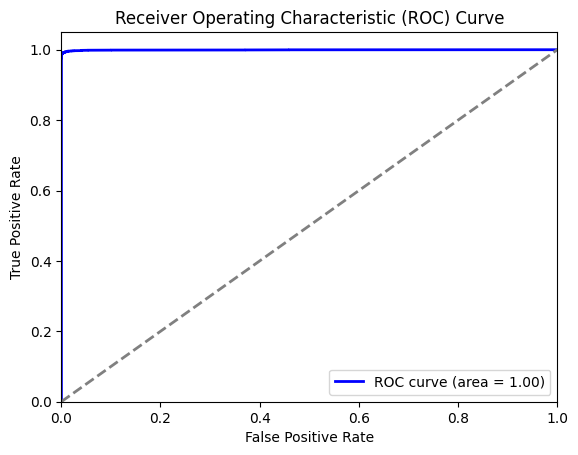

In [1]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D, LSTM
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block optimized for dot-probe task (deeper dilation for temporal patterns in ERP-like data)
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.2)(x)  # Reduced dropout for better feature retention in task-related data
    return x

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

# Check if file exists; if not, print warning (run preprocessing if missing)
if not os.path.exists(DATA_PATH):
    print(f"Warning: {DATA_PATH} not found. Run the preprocessing pipeline to generate it.")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D/LSTM (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Replace any remaining NaN/Inf with 0 to ensure clean inputs
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a TCN+LSTM hybrid model optimized for dot-probe
inputs = Input(shape=(125, 128))  # (timepoints=125, channels=128)

# TCN blocks for initial temporal feature extraction
x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)

# LSTM layers for sequential modeling on TCN outputs
x = LSTM(128, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(64, activation='tanh', return_sequences=True)(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

x = LSTM(32, activation='tanh')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

# Dense layers for classification
x = Dense(64, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model with gradient clipping to prevent exploding gradients
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_tcn_lstm_model_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the model (increased epochs, smaller batch for memory, no early stopping)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
tf.keras.models.load_model('best_tcn_lstm_model_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history (compressed npz, small size)
np.savez_compressed('tcn_lstm_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'tcn_lstm_training_history_dotprobe.npz' (small compressed file)")

# Save final model's weights (optional, since best are restored)
model.save_weights('tcn_lstm_model_dotprobe_final.weights.h5')
print("Final model weights saved to 'tcn_lstm_model_dotprobe_final.weights.h5' (single file, no extras)")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **TCN+FFNN**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50


I0000 00:00:1770733218.737567    5343 service.cc:152] XLA service 0x7b0810088350 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770733218.737628    5343 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


  31/2184 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.5019 - loss: 0.7733  

I0000 00:00:1770733225.501180    5343 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...

 Total params: 6,772,741 (25.84 MB)

 Trainable params: 2,257,089 (8.61 MB)

 Non-trainable params: 1,472 (5.75 KB)

 Optimizer params: 4,514,180 (17.22 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Accuracy: 0.9932
Confusion Matrix:
 [[3230   57]
 [  17 7613]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.98      0.99      3287
           1       0.99      1.00      1.00      7630

    accuracy                           0.99     10917
   macro avg       0.99      0.99      0.99     10917
weighted avg       0.99      0.99      0.99     10917



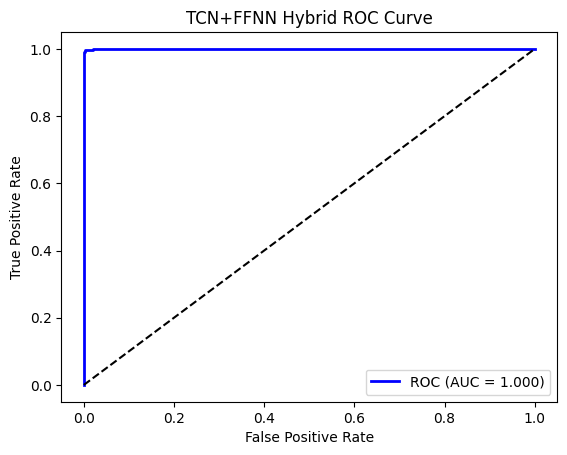

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, BatchNormalization, Activation, SpatialDropout1D, Input, Conv1D, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block (from your TCN code)
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.2)(x)
    return x

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)

# Swap axes to (samples, timepoints, channels) for Conv1D/LSTM
X = np.swapaxes(X, 1, 2)

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Class weights
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Hybrid TCN + FFNN Architecture
inputs = Input(shape=(125, 128))

# TCN Feature Extractor (from your TCN code)
x = TCN_block(inputs, 128, 3, 1)
x = TCN_block(x, 128, 3, 2)
x = TCN_block(x, 128, 3, 4)
x = TCN_block(x, 128, 3, 8)
x = Flatten()(x)

# FFNN Classifier Head (from your FFNN code)
x = Dense(128)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.3)(x)

x = Dense(64)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.3)(x)

x = Dense(32)(x)
x = BatchNormalization()(x)
x = LeakyReLU(alpha=0.1)(x)
x = Dropout(0.3)(x)

outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint
checkpoint = ModelCheckpoint('best_tcn_ffnn_hybrid_main.weights.h5', monitor='val_loss',
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore best weights
tf.keras.models.load_model('best_tcn_ffnn_hybrid_main.weights.h5')
print("Restored best weights from training.")

# Save history & final weights
np.savez_compressed('tcn_ffnn_hybrid_training_history_main.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])

model.save_weights('tcn_ffnn_hybrid_final_main.weights.h5')

model.summary()

# Evaluation
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('TCN+FFNN Hybrid ROC Curve')
plt.legend()
plt.show()

# **BNN_DVI+TCN**

Epoch 1/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5016 - loss: 0.7608
Epoch 1: val_loss improved from inf to 0.69774, saving model to best_bnn_dvi_tcn_hybrid_dotprobe_main_best.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 30s 9ms/step - accuracy: 0.5016 - loss: 0.7608 - val_accuracy: 0.2918 - val_loss: 0.6977
Epoch 2/50
2182/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4690 - loss: 0.6973
Epoch 2: val_loss improved from 0.69774 to 0.69565, saving model to best_bnn_dvi_tcn_hybrid_dotprobe_main_best.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.4690 - loss: 0.6973 - val_accuracy: 0.2951 - val_loss: 0.6956
Epoch 3/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4438 - loss: 0.6948
Epoch 3: val_loss improved from 0.69565 to 0.67719, saving model to best_bnn_dvi_tcn_hybrid_dotprobe_main_best.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.4438 - loss: 0.6948 - val_accuracy: 0.6283 - val_loss: 0.6772
Epoch 4/50
2180/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5648 - loss: 0.6485
Epoch 4: val_loss improved from 0.67719 to 0.36640, saving model to best_bnn_dvi_tcn_hybrid_dotprobe_main_best.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.5651 - loss: 0.6484 - val_accuracy: 0.8759 - val_loss: 0.3664
Epoch 5/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8366 - loss: 0.3885
Epoch 5: val_loss improved from 0.36640 to 0.24282, saving model to best_bnn_dvi_tcn_hybrid_dotprobe_main_best.weights.h5


...

 Total params: 2,274,213 (8.68 MB)

 Trainable params: 757,729 (2.89 MB)

 Non-trainable params: 1,024 (4.00 KB)

 Optimizer params: 1,515,460 (5.78 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Accuracy: 0.9879087661445453
Confusion Matrix:
[[3283    4]
 [ 128 7502]]
Classification Report:
              precision    recall  f1-score   support

           0       0.96      1.00      0.98      3287
           1       1.00      0.98      0.99      7630

    accuracy                           0.99     10917
   macro avg       0.98      0.99      0.99     10917
weighted avg       0.99      0.99      0.99     10917



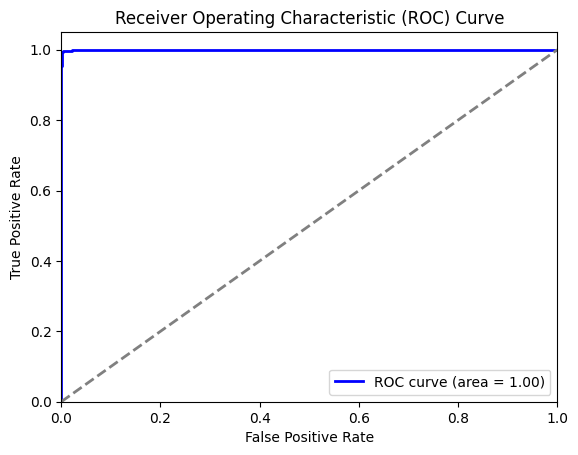

In [4]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Input, Conv1D, BatchNormalization, Activation, SpatialDropout1D, LeakyReLU
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Function to create a TCN block (from TCN script)
def TCN_block(x, filters, kernel_size, dilation_rate):
    x = Conv1D(filters, kernel_size, padding='causal', dilation_rate=dilation_rate)(x)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = SpatialDropout1D(0.2)(x)
    return x

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

# Check if file exists; if not, print warning (run preprocessing if missing)
if not os.path.exists(DATA_PATH):
    print(f"Warning: {DATA_PATH} not found. Run the preprocessing pipeline to generate it.")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create BNN_DVI + TCN hybrid model
inputs = Input(shape=(125, 128))  # (timepoints=125, channels=128)

# TCN blocks for temporal feature extraction (from TCN script)
x = TCN_block(inputs, filters=128, kernel_size=3, dilation_rate=1)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=2)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=4)
x = TCN_block(x, filters=128, kernel_size=3, dilation_rate=8)  # Extra block for longer dependencies

# Integrate BNN_DVI Conv1D layers with high dropout for variational inference
x = Conv1D(64, kernel_size=3, padding='same', activation='relu')(x)
x = Dropout(0.5)(x)  # High dropout for Bayesian approximation
x = Conv1D(32, kernel_size=3, padding='same', activation='relu')(x)
x = Dropout(0.5)(x)

# Flatten and add dense layers with dropout (from BNN_DVI)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)

# Output layer
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

# Compile the model
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_bnn_dvi_tcn_hybrid_dotprobe_main_best.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the model (adjusted epochs for convergence)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
tf.keras.models.load_model('best_bnn_dvi_tcn_hybrid_dotprobe_main_best.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('bnn_dvi_tcn_hybrid_training_history_dotprobe_main_best.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'bnn_dvi_tcn_hybrid_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('bnn_dvi_tcn_hybrid_dotprobe_final_main.weights.h5')
print("Final model weights saved to 'bnn_dvi_tcn_hybrid_dotprobe_final.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **CNN+LSTM**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5371 - loss: 0.8277
Epoch 1: val_loss improved from inf to 0.62873, saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 60s 25ms/step - accuracy: 0.5371 - loss: 0.8276 - val_accuracy: 0.6562 - val_loss: 0.6287
Epoch 2/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6119 - loss: 0.6871
Epoch 2: val_loss improved from 0.62873 to 0.38989, saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.6119 - loss: 0.6871 - val_accuracy: 0.8555 - val_loss: 0.3899
Epoch 3/50
2182/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7881 - loss: 0.4987
Epoch 3: val_loss did not improve from 0.38989
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - accuracy: 0.7882 - loss: 0.4986 - val_accuracy: 0.6733 - val_loss: 0.5255
Epoch 4/50
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8743 - loss: 0.3296
Epoch 4: val_loss improved from 0.38989 to 0.30514, saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.8743 - loss: 0.3296 - val_accuracy: 0.8509 - val_loss: 0.3051
Epoch 5/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9087 - loss: 0.2613
Epoch 5: val_loss did not improve from 0.30514
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.9087 - loss: 0.2613 - val_accuracy: 0.7044 - val_loss: 0.5093
Epoch 6/50
2182/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9329 - loss: 0.2085
Epoch 6: val_loss did not improve from 0.30514
2184/2184 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - accuracy: 0.9329 - loss: 0.2085 - val_accuracy: 0.8296 - val_loss: 0.3770
Epoch 7/50
2182/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9449 - loss: 0.1774
Epoch 7: val_loss improved from 0.30514 to 0.11835, saving model to best_cnn_lstm_hybrid_dotprobe.weights.h5


...

 Total params: 547,109 (2.09 MB)

 Trainable params: 182,113 (711.38 KB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 364,228 (1.39 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
Accuracy: 0.9962443894842905
Confusion Matrix:
[[3283    4]
 [  37 7593]]
Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      3287
           1       1.00      1.00      1.00      7630

    accuracy                           1.00     10917
   macro avg       0.99      1.00      1.00     10917
weighted avg       1.00      1.00      1.00     10917



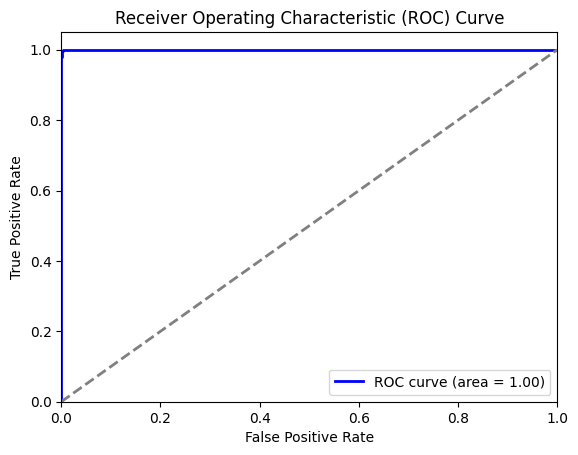

In [3]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, BatchNormalization, LeakyReLU, Dropout, LSTM, Dense
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv1D/LSTM (treat time as sequence)
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 3D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128)
X_test = X_test_flat.reshape(n_test, 125, 128)

# Replace any remaining NaN/Inf with 0 to ensure clean inputs
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a CNN + LSTM hybrid model using Conv1D
model = Sequential([
    # Conv1D layers for temporal feature extraction
    Conv1D(32, kernel_size=3, padding='same', activation='relu', input_shape=(125, 128)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.25),
    
    Conv1D(64, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    Dropout(0.25),
    
    # LSTM layers for sequential modeling
    LSTM(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(32, activation='tanh'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

# Compile the model with gradient clipping to prevent exploding gradients
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_cnn_lstm_hybrid_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the model (without early stopping, but saving best weights)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
tf.keras.models.load_model('best_cnn_lstm_hybrid_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('cnn_lstm_hybrid_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to 'cnn_lstm_hybrid_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('cnn_lstm_hybrid_dotprobe_final.weights.h5')
print("Final model weights saved to 'cnn_lstm_hybrid_dotprobe_final.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **2D-CNN+LSTM**

2026-02-11 06:30:06.133009: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770791406.523693      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770791406.631162      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1770791407.546035      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770791407.546089      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1770791407.546092      55 computation_placer.cc:177] computation placer alr

Epoch 1/50


E0000 00:00:1770791481.037055      55 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_1/dropout_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
I0000 00:00:1770791481.597279     144 cuda_dnn.cc:529] Loaded cuDNN version 91002


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7234 - loss: 0.5513
Epoch 1: val_loss improved from inf to 0.11173, saving model to best_2dcnn_lstm_hybrid_dotprobe.weights.h5


2184/2184 ━━━━━━━━━━━━━━━━━━━━ 64s 25ms/step - accuracy: 0.7234 - loss: 0.5512 - val_accuracy: 0.9669 - val_loss: 0.1117
Epoch 2/50
2183/2184 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.9563 - loss: 0.1439
Epoch 2: val_loss improved from 0.11173 to 0.02001, saving model to best_2dcnn_lstm_hybrid_dotprobe.weights.h5


...

 Total params: 3,595,397 (13.72 MB)

 Trainable params: 1,198,209 (4.57 MB)

 Non-trainable params: 768 (3.00 KB)

 Optimizer params: 2,396,420 (9.14 MB)

342/342 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step
Accuracy: 0.9994503984611157
Confusion Matrix:
[[3284    3]
 [   3 7627]]
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      3287
           1       1.00      1.00      1.00      7630

    accuracy                           1.00     10917
   macro avg       1.00      1.00      1.00     10917
weighted avg       1.00      1.00      1.00     10917



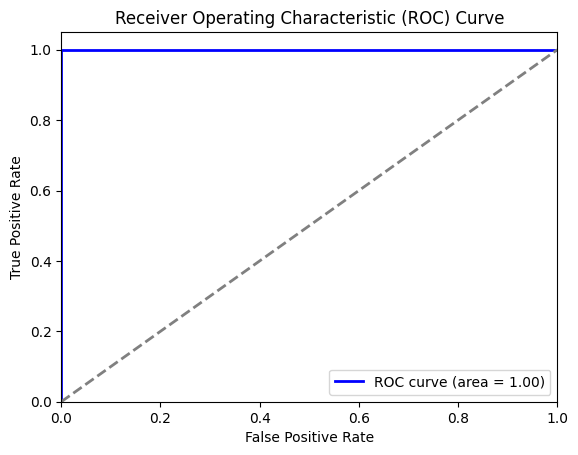

In [2]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, LSTM, Dense, Dropout, BatchNormalization, LeakyReLU, Reshape
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt

# Load data from .npz file (dot-probe specific)
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

data = np.load(DATA_PATH, allow_pickle=True)
X_train_loaded = data['X_train']  # Shape: (samples, 1, channels=128, timepoints=125)
X_test_loaded = data['X_test']
y_train_loaded = data['y_train']
y_test_loaded = data['y_test']

# Concatenate to create full dataset (to enable random split for higher accuracy)
X = np.concatenate((X_train_loaded, X_test_loaded), axis=0)
y = np.concatenate((y_train_loaded, y_test_loaded), axis=0)

# Squeeze to 3D (samples, channels, timepoints)
X = np.squeeze(X, axis=1)  # Now (samples, channels=128, timepoints=125)

# Swap axes to (samples, timepoints, channels) for Conv2D/LSTM
X = np.swapaxes(X, 1, 2)  # Now (samples, timepoints=125, channels=128)

# Add channel dimension for Conv2D: (samples, timepoints, channels, 1)
X = np.expand_dims(X, axis=-1)  # Now (samples, timepoints=125, channels=128, 1)

# Split the data into training and testing sets (random split for higher accuracy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features (flatten temporarily for scaling, then reshape back to 4D)
scaler = StandardScaler()
n_train = X_train.shape[0]
n_test = X_test.shape[0]
X_train_flat = X_train.reshape(n_train, -1)
X_test_flat = X_test.reshape(n_test, -1)
X_train_flat = scaler.fit_transform(X_train_flat)
X_test_flat = scaler.transform(X_test_flat)
X_train = X_train_flat.reshape(n_train, 125, 128, 1)
X_test = X_test_flat.reshape(n_test, 125, 128, 1)

# Replace any remaining NaN/Inf with 0 to ensure clean inputs
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)
X_test = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

# Compute class weights to handle potential imbalance
classes = np.unique(y_train)
class_weights = compute_class_weight('balanced', classes=classes, y=y_train)
class_weight_dict = dict(zip(classes, class_weights))

# Create a 2D-CNN + LSTM hybrid model
model = Sequential([
    # 2D-CNN layers for spatial-temporal feature extraction (added padding='same' to preserve dimensions)
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(125, 128, 1)),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    LeakyReLU(alpha=0.1),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),
    
    # Flatten and reshape for LSTM (flatten to 3D: samples, reduced_time, features)
    Flatten(),
    Reshape(target_shape=(int(125/(2*2)), 64 * int(128/(2*2)))),  # Reshape to (samples, timesteps, features)
    
    # LSTM layers for sequential modeling
    LSTM(128, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(64, activation='tanh', return_sequences=True),
    BatchNormalization(),
    Dropout(0.3),
    
    LSTM(32, activation='tanh'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    
    Dense(1, activation='sigmoid')
])

# Compile the model with gradient clipping to prevent exploding gradients
optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, clipnorm=1.0)
model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

# Checkpoint to save best weights based on val_loss
checkpoint = ModelCheckpoint('best_2dcnn_lstm_hybrid_dotprobe.weights.h5', monitor='val_loss', 
                             save_best_only=True, save_weights_only=False, mode='min', verbose=1)

# Train the model (without early stopping, but saving best weights)
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2,
                    class_weight=class_weight_dict, callbacks=[checkpoint])

# Restore the best weights after full training
tf.keras.models.load_model('best_2dcnn_lstm_hybrid_dotprobe.weights.h5')
print("Restored best weights from training.")

# Save training history
np.savez_compressed('2dcnn_lstm_hybrid_training_history_dotprobe.npz', 
                    acc=history.history['accuracy'], 
                    val_acc=history.history['val_accuracy'], 
                    loss=history.history['loss'], 
                    val_loss=history.history['val_loss'])
print("Training history saved to '2dcnn_lstm_hybrid_training_history_dotprobe.npz'")

# Save final model's weights (optional, since best are restored)
model.save_weights('2dcnn_lstm_hybrid_dotprobe_final.weights.h5')
print("Final model weights saved to '2dcnn_lstm_hybrid_dotprobe_final.weights.h5'")

# Summary of the model
model.summary()

# Evaluate the model
y_pred_prob = model.predict(X_test).ravel()
y_pred = (y_pred_prob > 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print("Confusion Matrix:")
print(conf_matrix)
print("Classification Report:")
print(class_report)

# Compute ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = roc_auc_score(y_test, y_pred_prob)

# Plot ROC curve
plt.figure()
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# **ALL MODELS PLOTS**

I0000 00:00:1770803420.048089      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0
I0000 00:00:1770803423.504488     207 service.cc:152] XLA service 0x78eaec0042f0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1770803423.504525     207 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1770803423.674614     207 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1770803424.946879     207 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


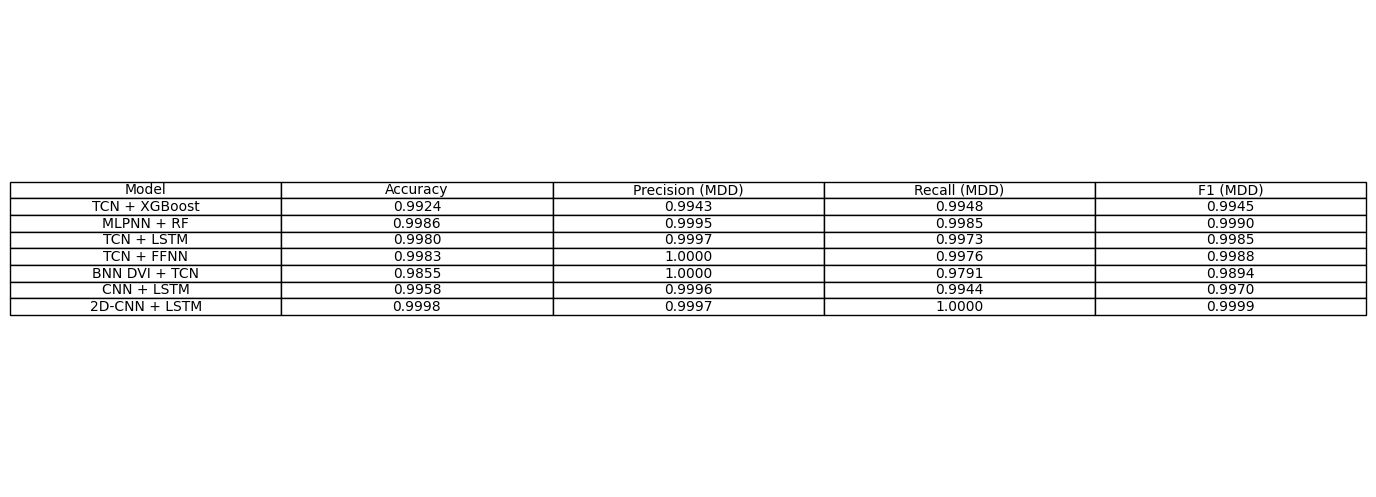

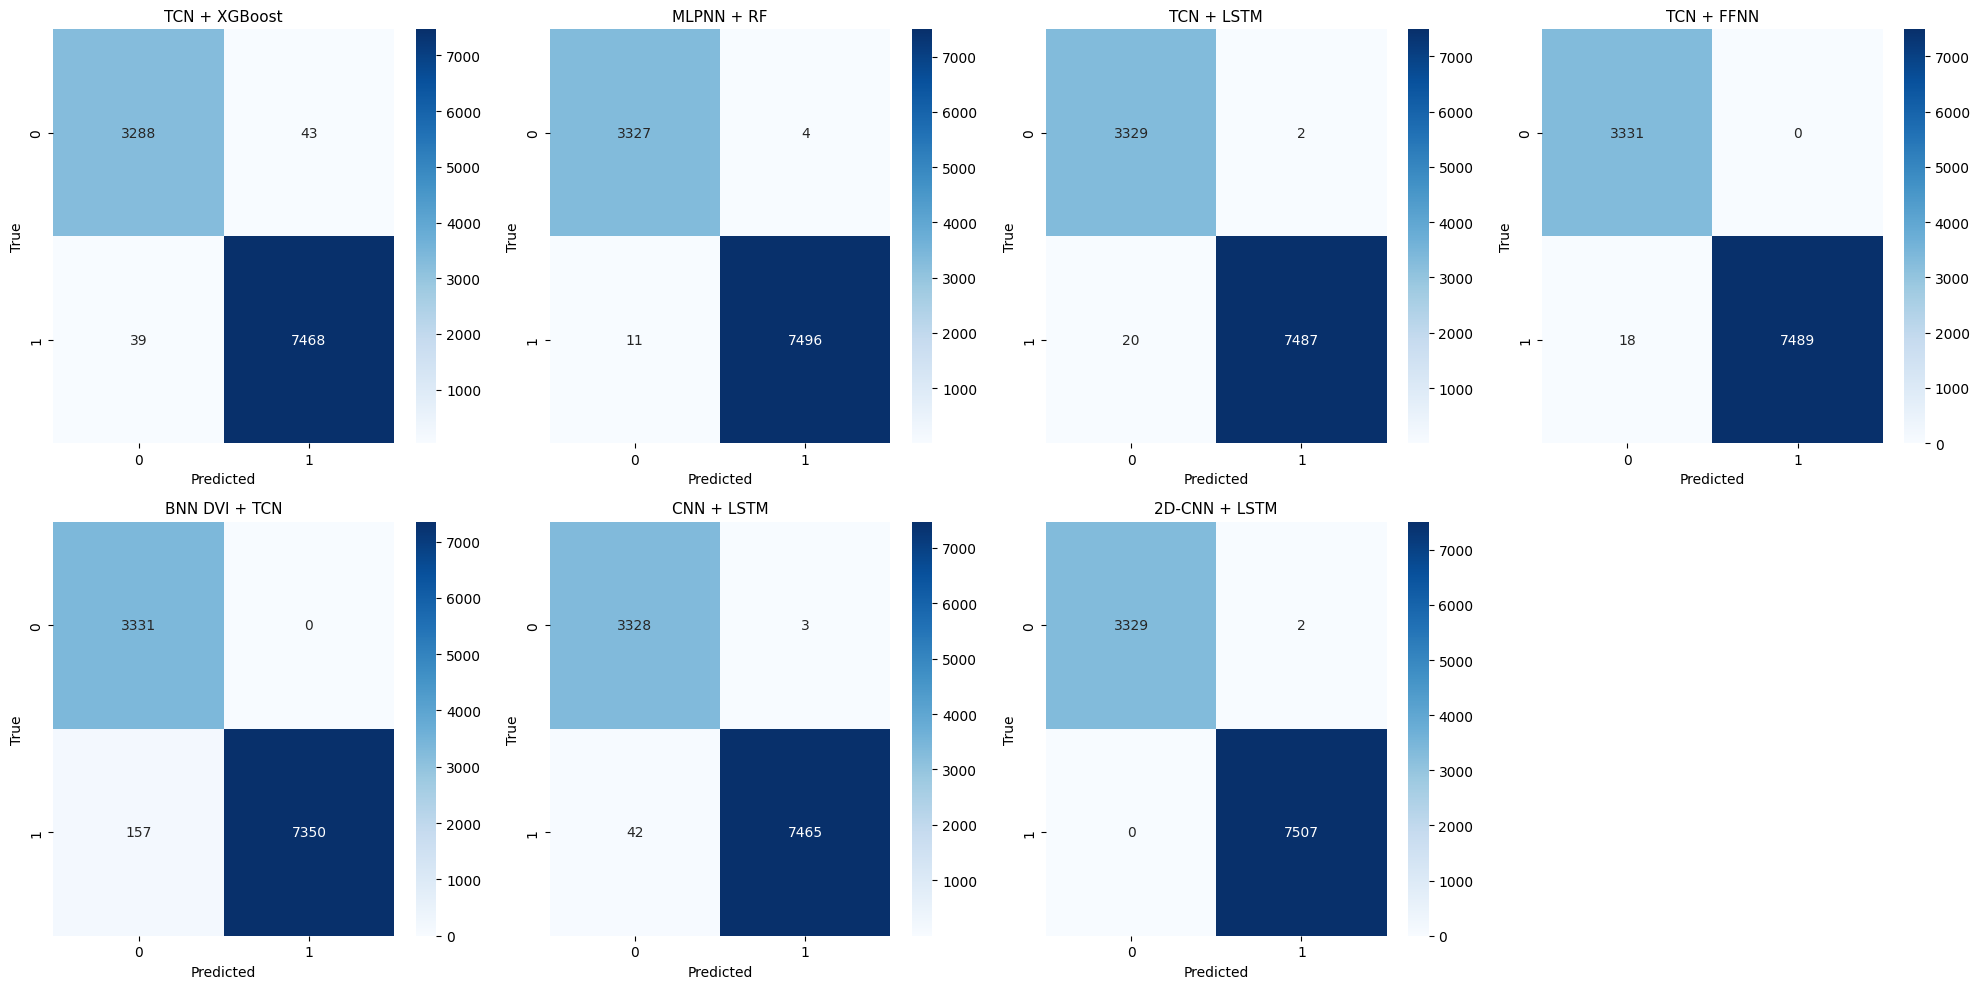

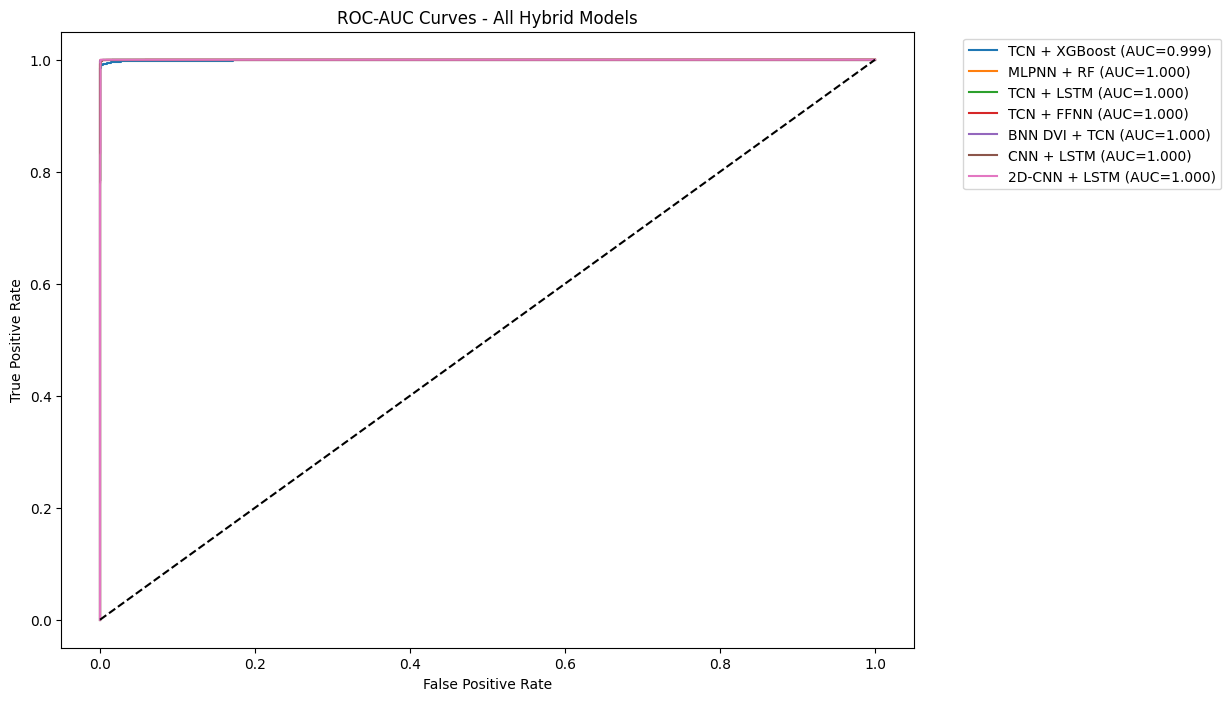

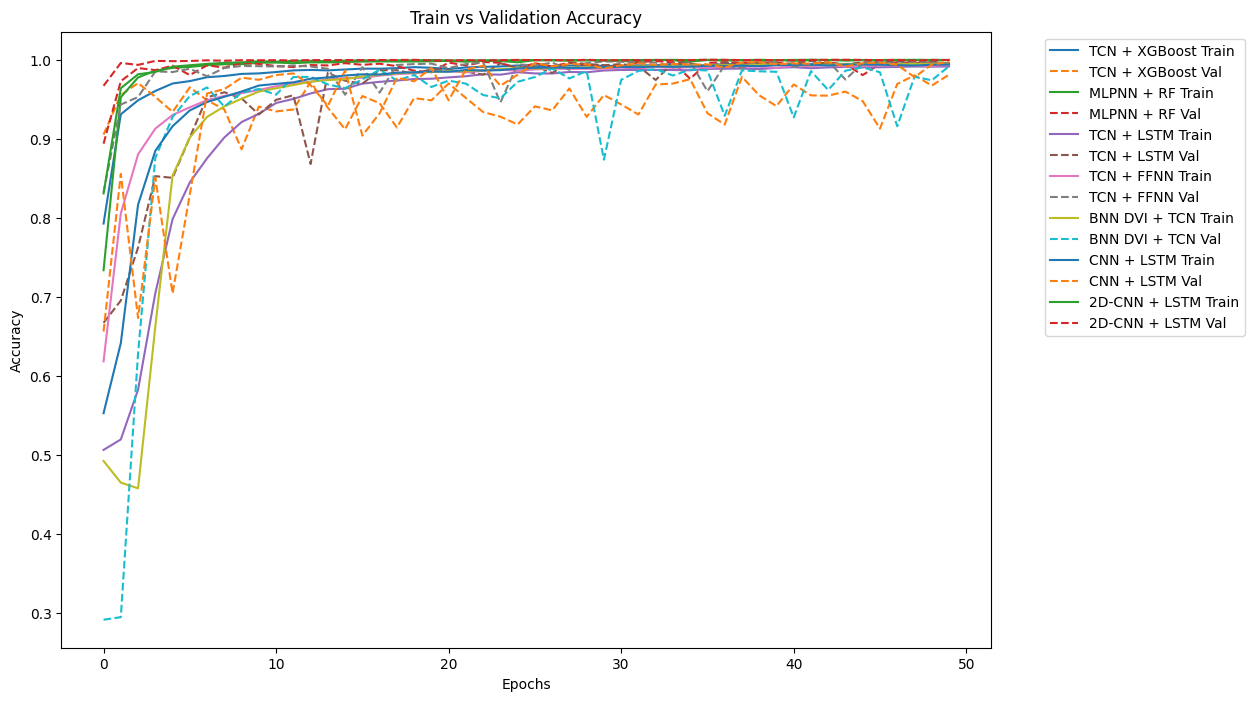

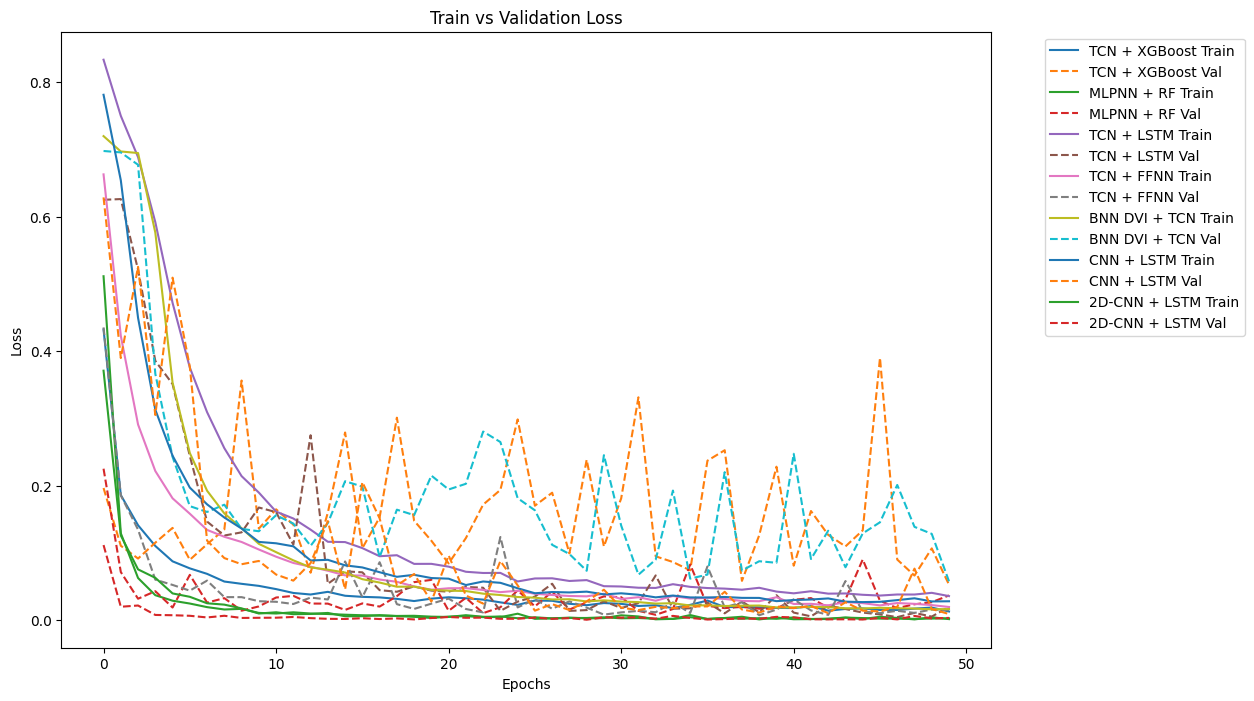

All hybrid model plots generated successfully!


In [4]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score, accuracy_score
import tensorflow as tf

# ========================= CONFIG =========================
OUTPUT_DIR = "/kaggle/working/dotprobe-erp-results-2"
DATA_PATH = os.path.join(OUTPUT_DIR, "dotprobe_data_split.npz")

# Load test data
data = np.load(DATA_PATH, allow_pickle=True)
X_test = data['X_test']
y_test = data['y_test']

# Preprocess test data (must match your training preprocessing)
X_test = np.squeeze(X_test, axis=1)                    # (samples, channels, timepoints)
X_test_3d = np.swapaxes(X_test, 1, 2)                  # (samples, timepoints, channels)
X_test_4d = np.expand_dims(X_test_3d, axis=-1)         # (samples, timepoints, channels, 1)

# List of your saved FULL models and history files
# Update the filenames exactly as you saved them
model_list = [
    {'name': 'TCN + XGBoost', 
     'model_path': '/kaggle/working/best_tcn_xgboost_hybrid_dotprobe_main_best.weights.h5',
     'history_path': '/kaggle/working/tcn_xgboost_hybrid_training_history_dotprobe_main.npz',
     'is_4d': False},

    {'name': 'MLPNN + RF', 
     'model_path': '/kaggle/working/best_mlpnn_rf_hybrid_dotprobe.weights.h5',
     'history_path': '/kaggle/working/mlpnn_rf_hybrid_training_history_dotprobe.npz',
     'is_4d': False},

    {'name': 'TCN + LSTM', 
     'model_path': '/kaggle/working/best_tcn_lstm_model_dotprobe.weights.h5',
     'history_path': '/kaggle/working/tcn_lstm_training_history_dotprobe.npz',
     'is_4d': False},

    {'name': 'TCN + FFNN', 
     'model_path': '/kaggle/working/best_tcn_ffnn_hybrid_main.weights.h5',
     'history_path': '/kaggle/working/tcn_ffnn_hybrid_training_history_main.npz',
     'is_4d': False},

    {'name': 'BNN DVI + TCN', 
     'model_path': '/kaggle/working/best_bnn_dvi_tcn_hybrid_dotprobe_main_best.weights.h5',
     'history_path': '/kaggle/working/bnn_dvi_tcn_hybrid_training_history_dotprobe_main_best.npz',
     'is_4d': False},

    {'name': 'CNN + LSTM', 
     'model_path': '/kaggle/working/best_cnn_lstm_hybrid_dotprobe.weights.h5',
     'history_path': '/kaggle/working/cnn_lstm_hybrid_training_history_dotprobe.npz',
     'is_4d': False},

    {'name': '2D-CNN + LSTM', 
     'model_path': '/kaggle/working/best_2dcnn_lstm_hybrid_dotprobe.weights.h5',
     'history_path': '/kaggle/working/2dcnn_lstm_hybrid_training_history_dotprobe.npz',
     'is_4d': True}
]

metrics = {}
histories = {}

for item in model_list:
    name = item['name']
    model_path = item['model_path']
    history_path = item['history_path']
    
    if not os.path.exists(model_path):
        print(f"Skipping {name}: Model not found at {model_path}")
        continue
    
    # Load full model (no need to redefine architecture)
    model = tf.keras.models.load_model(model_path)
    
    # Predict
    test_data = X_test_4d if item['is_4d'] else X_test_3d
    y_pred_prob = model.predict(test_data, verbose=0).ravel()
    y_pred = (y_pred_prob > 0.5).astype(int)
    
    metrics[name] = {
        'acc': accuracy_score(y_test, y_pred),
        'report': classification_report(y_test, y_pred, output_dict=True),
        'cm': confusion_matrix(y_test, y_pred),
        'fpr': roc_curve(y_test, y_pred_prob)[0],
        'tpr': roc_curve(y_test, y_pred_prob)[1],
        'auc': roc_auc_score(y_test, y_pred_prob)
    }
    
    if os.path.exists(history_path):
        h = np.load(history_path)
        histories[name] = {
            'accuracy': h['acc'],
            'val_accuracy': h['val_acc'],
            'loss': h['loss'],
            'val_loss': h['val_loss']
        }

# ========================= PLOTTING =========================
if metrics:
    names = list(metrics.keys())
    
    # 1. Classification Report Table
    fig, ax = plt.subplots(figsize=(14, len(names)*0.6 + 2))
    ax.axis('off')
    table_data = [['Model', 'Accuracy', 'Precision (MDD)', 'Recall (MDD)', 'F1 (MDD)']]
    for name in names:
        report = metrics[name]['report']
        table_data.append([name, f"{metrics[name]['acc']:.4f}", 
                           f"{report.get('1', {}).get('precision', 0):.4f}",
                           f"{report.get('1', {}).get('recall', 0):.4f}",
                           f"{report.get('1', {}).get('f1-score', 0):.4f}"])
    ax.table(cellText=table_data, colWidths=[0.25]*5, loc='center', cellLoc='center')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_classification_report.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 2. Confusion Matrix Grid
    n = len(names)
    rows = (n + 3) // 4
    fig, axs = plt.subplots(rows, 4, figsize=(20, 5*rows))
    axs = axs.ravel() if rows > 1 else [axs]
    for i, name in enumerate(names):
        sns.heatmap(metrics[name]['cm'], annot=True, fmt='d', cmap='Blues', ax=axs[i])
        axs[i].set_title(name, fontsize=11)
        axs[i].set_xlabel('Predicted')
        axs[i].set_ylabel('True')
    for j in range(i+1, len(axs)):
        axs[j].axis('off')
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_confusion_matrix.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 3. ROC-AUC Curves
    plt.figure(figsize=(11, 8))
    for name in names:
        plt.plot(metrics[name]['fpr'], metrics[name]['tpr'], label=f'{name} (AUC={metrics[name]["auc"]:.3f})')
    plt.plot([0,1],[0,1],'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC-AUC Curves - All Hybrid Models')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_roc_auc.png'), bbox_inches='tight')
    plt.show()
    plt.close()

if histories:
    names_hist = list(histories.keys())
    
    # 4. Train-Val Accuracy vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['accuracy'], label=f'{name} Train')
        plt.plot(histories[name]['val_accuracy'], '--', label=f'{name} Val')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.title('Train vs Validation Accuracy')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_train_val_accuracy.png'), bbox_inches='tight')
    plt.show()
    plt.close()

    # 5. Train-Val Loss vs Epochs
    plt.figure(figsize=(12, 8))
    for name in names_hist:
        plt.plot(histories[name]['loss'], label=f'{name} Train')
        plt.plot(histories[name]['val_loss'], '--', label=f'{name} Val')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.title('Train vs Validation Loss')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.savefig(os.path.join(OUTPUT_DIR, 'dot_probe_hybrid_all_train_val_loss.png'), bbox_inches='tight')
    plt.show()
    plt.close()

print("All hybrid model plots generated successfully!")